In [2]:
import pandas as pd
from astropy.coordinates import SkyCoord
import os
import numpy as np
from scipy.interpolate import interp1d

from frb.dm import igm
z_interp = np.geomspace(0.001,1,num = 30)
dm_igm_interp = []
for ii, z_interp_i in enumerate(z_interp):
    dm_igm_interp.append(igm.average_DM(z_interp_i))
    print(ii,'/30')
dm_igm_interp= np.array([di.value for di in dm_igm_interp])


0 /30
1 /30
2 /30
3 /30
4 /30
5 /30
6 /30
7 /30
8 /30
9 /30
10 /30
11 /30
12 /30
13 /30
14 /30
15 /30
16 /30
17 /30
18 /30
19 /30
20 /30
21 /30
22 /30
23 /30
24 /30
25 /30
26 /30
27 /30
28 /30
29 /30


In [534]:
import dustmaps
from dustmaps.sfd import SFDQuery
import dustmaps.sfd as sfd
sfd = SFDQuery()
e_b_minus_v = sfd(SkyCoord('16h02m04.272s -11d17m17.32s',frame = 'icrs')) # amplitude of extinction curve vs wavelength
r_v = 3.1 # shape
a_v = r_v * e_b_minus_v # get A_v = R_V * E(B-V) ??? Let's pretend I understand why this is the case
import extinction
evs = []
ext_value_mags = extinction.fm07(wave = np.array([12000.0]), a_v = a_v, unit = 'aa') # extrapolate extinction to 6000 angstroms
evs.append(ext_value_mags)
evs = np.squeeze(evs)        

In [535]:
import numpy as np

import pandas as pd
import os
import json
from frb.surveys.panstarrs import Pan_STARRS_Survey
from frb.surveys.decals import DECaL_Survey
from astropy.coordinates import SkyCoord
from astropy import units as u
from astropy.cosmology import Planck18
import astropy.units as u
import pyne2001
import astropy.coordinates as coord
from frb.surveys.decals import DECaL_Survey
from frb.surveys.panstarrs import Pan_STARRS_Survey

def get_ne2001(c_icrs,get_scatt = True):
    dm_ne2001 = np.zeros(len(c_icrs))
    tau600_ne2001 = np.zeros(len(c_icrs))

    for ii,(gl,gb) in enumerate(zip(c_icrs.galactic.l,c_icrs.galactic.b)):
        ne2001_pred = pyne2001.get_dm_full(gl.value,gb.value,dist_kpc = 100.0)
        #print(f"dist: {ne2001_pred['DIST']}")
        dm_ne2001[ii] = ne2001_pred['DM']
        tau600_ne2001[ii] = ne2001_pred['TAU'] * (1/0.6)**4
    if get_scatt:
        return dm_ne2001,tau600_ne2001
    else:
        return dm_ne2001

def calc_ne2001(df):
    if 'primary_ra' in df.keys():
        sources = coord.SkyCoord(df['primary_ra'],df['primary_dec'],unit = 'deg',frame = 'icrs')
    elif 'frb_ra' in df.keys():
        sources = coord.SkyCoord(df['frb_ra'],df['frb_dec'],unit = 'deg',frame = 'icrs')
    dm_ne2001,tau600_ne2001 = get_ne2001(sources,get_scatt=True)
    df['DM_NE2001'] = dm_ne2001
    df['tau_NE2001_600'] = tau600_ne2001
    return df

def calc_extinction_fm07(df):
    """Add Galactic extinction from F & M 2007, given either FRB coordinates or HG coordinates in a pandas dataframe"""
    import dustmaps
    from dustmaps.sfd import SFDQuery
    import dustmaps.sfd as sfd
    sfd = SFDQuery()
    if 'primary_ra' in df.keys(): # use hg coords if we have them
        sources = coord.SkyCoord(df['primary_ra'],df['primary_dec'],unit = 'deg',frame = 'icrs')
    elif 'frb_ra' in df.keys(): # otherwise use FRB coords
        sources = coord.SkyCoord(df['frb_ra'],df['frb_dec'],unit = 'deg',frame = 'icrs')
    e_b_minus_v = sfd(sources) # amplitude of extinction curve vs wavelength
    r_v = 3.1 # shape
    a_v = r_v * e_b_minus_v # get A_v = R_V * E(B-V) ??? Let's pretend I understand why this is the case
    import extinction
    evs = []
    for av in a_v:
        ext_value_mags = extinction.fm07(wave = np.array([6000.0]), a_v = av, unit = 'aa') # extrapolate extinction to 6000 angstroms
        evs.append(ext_value_mags)
    evs = np.squeeze(evs)        
    df['extinction_mags'] = evs
    return df

def calc_yt20(df):
    def calculate_halo_dm_yt20(l, b):
        coeffs = np.array(
            [
                [250.12, -871.06, 1877.5, -2553.0, 2181.3, -1127.5, 321.72, -38.905],
                [-154.82, 783.43, -1593.9, 1727.6, -1046.5, 332.09, -42.815, 0],
                [-116.72, -76.815, 428.49, -419.00, 174.60, -27.610, 0, 0],
                [216.67, -193.30, 12.234, 32.145, -8.3602, 0, 0, 0],
                [-129.95, 103.80, -22.800, 0.44171, 0, 0, 0, 0],
                [39.652, -21.398, 2.7694, 0, 0, 0, 0, 0],
                [-6.1926, 1.6162, 0, 0, 0, 0, 0, 0],
                [0.39346, 0, 0, 0, 0, 0, 0, 0],
            ]
        )
        l = np.mod(l + 180,360) - 180
        l_absolute = np.abs(np.deg2rad(l))
        b_absolute = np.abs(np.deg2rad(b))
        DM_halo = 0
        for ii in range(8):
            for jj in range(8):
                DM_halo += coeffs[ii, jj] * l_absolute ** ii * b_absolute ** jj
        return DM_halo # u.pc / u.cm ** 3
    if 'primary_ra' in df.keys():
        sources = coord.SkyCoord(df['primary_ra'],df['primary_dec'],unit = 'deg',frame = 'icrs')
    elif 'frb_ra' in df.keys():
        sources = coord.SkyCoord(df['frb_ra'],df['frb_dec'],unit = 'deg',frame = 'icrs')
    df['DM_YT20'] = calculate_halo_dm_yt20(l = sources.galactic.l.deg,b = sources.galactic.b.deg)
    return df

def calc_dm_igm(df,source = 'zspec'):
    from frb.dm import igm
    for evid,row in df.iterrows():
        if source == 'zphot': 
            best_redshift = row['primary_z_phot_median']
        elif source == 'zspec':
            best_redshift = row['primary_z_spec']
        elif source == 'mix':
            if row['primary_z_spec'] > 0:
                best_redshift = row['primary_z_spec']
            elif row['primary_z_phot_median'] > 0:
                best_redshift = row['primary_z_phot_median']
            else:
                best_redshift = -1
        if best_redshift > 0:
            dm_igm = np.interp(xp = z_interp, fp = dm_igm_interp, x = best_redshift)
            df.at[evid,'dm_igm'] = dm_igm
        else:
            df.at[evid,'dm_igm'] = np.nan
    return df

def calc_dmh(df):
    dmh = (df['DM'] - df['dm_igm'] - df['DM_NE2001'] - df['DM_YT20']) / (1 + df['primary_z_spec'])
    df['DM_host_restframe'] = dmh
    return df

def calc_Mr(df,source='zspec'):
    if source == 'zspec':
        dist_mod = Planck18.distmod(np.clip(df['primary_z_spec'].values,a_min = 0,a_max = np.inf)).value
    if source == 'zphot':
        dist_mod = Planck18.distmod(np.clip(df['primary_z_phot'].values,a_min = 0,a_max = np.inf)).value
    df['M_r'] = df['primary_mag'] - df['extinction_mags'] - dist_mod
    return df

# Leung 2024

In [536]:
final = pd.read_csv(os.path.join('/arc/home/calvin/kko_host_paper','data_products/kko_full_cat.csv'))
final.set_index('chime_event_id',inplace=True)

In [611]:
Planck18.angular_diameter_distance(0.06) * (8/3600) * (np.pi/180)

<Quantity 0.00958973 Mpc>

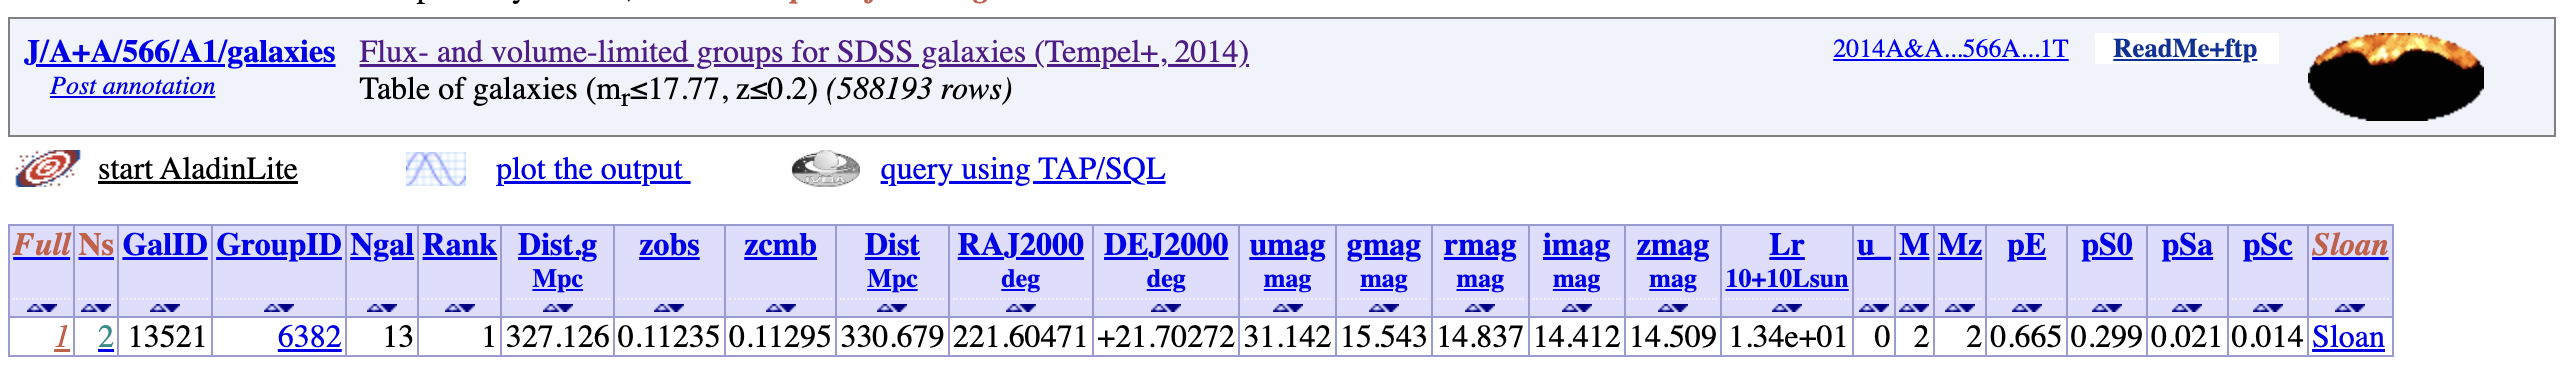

In [537]:
final[final['name'] == 'FRB20231204A'][['primary_ra','primary_dec','DM','dm_igm','DM_YT20','DM_NE2001','primary_z_spec','primary_mag']]

,primary_ra,primary_dec,DM,dm_igm,DM_YT20,DM_NE2001,primary_z_spec,primary_mag
chime_event_id,,,,,,,,
342256558,207.999403,48.120566,222.0,53.942359,32.003043,29.8287,0.0644,15.397451


In [610]:
final[final['name'] == 'FRB20231204A']

,name,ra_frb,dec_frb,b_err,a_err,gal_b,gal_l,DM_YT20,DM_NE2001,theta,...,secondary_mag,primary_z_spec_source,dm_igm,extinction_mags,flux,flux_err,fluence,fluence_err,M_r,DM_host_restframe
chime_event_id,,,,,,,,,,,,,,,,,,,,,
342256558,FRB20231204A,207.999034,48.115997,0.000556,0.007262,65.928146,97.623747,32.003043,29.8287,9.486636,...,15.903781,Lick-2024A-1,40.892086,0.051134,4.66,0.55,25.53,2.71,-22.032804,112.059536


# Bhardwaj 2024: the old R4 paper (20181030A) and also 4 new FRBs 
Add DM IGM, DM NE2001, DM YT20

In [538]:
coords_bhardwaj2024 = ['10h34m20.1s +73d45m05s','23h14m52s +48d20m25s',    '12h03m43s +27d33m09s',    '04h23m16s +16d04m02s',    '17h02m42s +21d34m35s']
scb =  SkyCoord(coords_bhardwaj2024,frame = 'icrs')
_bhardwaj2024 = {
    'name':   ['FRB20181030A','FRB20181220A', 'FRB20181223C', 'FRB20190418A', 'FRB20190425A'],
    'frb_ra': scb.ra.deg,
    'frb_dec': scb.dec.deg,
    'DM' : [103.5,209.4,112.5,184.5,128.2],
    'primary_z_spec': [0.004, 0.0275, 0.0302, 0.0715, 0.0312],
    'M_r': [-19.1, -19.71,-18.85, -20.93, -20.95]
}

bhardwaj2024 = pd.DataFrame(data = _bhardwaj2024)
sc_bhardwaj = SkyCoord(ra=bhardwaj2024['frb_ra'].values,
                  dec=bhardwaj2024['frb_dec'].values,unit = 'deg',frame = 'icrs') # baseband position
bhardwaj2024.insert(loc = 5, column = 'gal_l', value = sc_bhardwaj.galactic.l.deg)
bhardwaj2024.insert(loc = 5, column = 'gal_b', value = sc_bhardwaj.galactic.b.deg)
bhardwaj2024.set_index('name',inplace=True)
bhardwaj2024 = calc_yt20(bhardwaj2024)
bhardwaj2024 = calc_ne2001(bhardwaj2024)   
bhardwaj2024 = calc_dm_igm(bhardwaj2024,source = 'zspec')


# Michilli 2023: two new FRBs
But one is in the KKO sample

In [539]:

coords_michilli = ['4h22m44s +73d39m52s']
scm = SkyCoord(coords_michilli)
_michilli2023 = {
    'name': ['FRB20180814A'],
    'frb_ra': scm.ra.deg,
    'frb_dec': scm.dec.deg,
    'DM': 189.4, 
    'primary_z_spec': [0.068], 
    'M_r': [-20.78]
}
michilli2023 = pd.DataFrame(data = _michilli2023)
michilli2023 = calc_yt20(michilli2023)
michilli2023 = calc_ne2001(michilli2023)
michilli2023 = calc_dm_igm(michilli2023,source='zspec')
michilli2023.insert(loc = 5, column = 'gal_l', value = scm.galactic.l.deg)
michilli2023.insert(loc = 5, column = 'gal_b', value = scm.galactic.b.deg)
michilli2023.set_index('name',inplace=True)

# R117

In [540]:
coords_r117 = ['05h08m03.507s +26d03m38.50s']
scr = SkyCoord(coords_r117)
_r117 = {
    'name': ['FRB20201124A'],
    'frb_ra':  scr.ra.deg,
    'frb_dec': scr.dec.deg,
    'DM' : [413],
    'primary_z_spec': [0.09795],
    'primary_mag': [19.65]
}
r117 = pd.DataFrame(data = _r117)
r117 = calc_yt20(r117)
r117 = calc_ne2001(r117)
r117 = calc_dm_igm(r117,source='zspec')
r117.insert(loc = 5, column = 'gal_l', value = scr.galactic.l.deg)
r117.insert(loc = 5, column = 'gal_b', value = scr.galactic.b.deg)
r117.set_index('name',inplace=True)

# Gordon 2023
Add YT20, NE2001, reddening, and DM IGM

In [541]:
# Two new FRBs originally reported in Gordon 2023, according to Mohit (I presume he got everything)
coords_gordon2023 = ['13h19m13.97s −18d50m16.1s', '10h29m24.22s +01d21m39.4s']
sc_gordon = SkyCoord(coords_gordon2023,frame = 'icrs')
_gordon2023 = {
    'name': ['FRB20211127I','FRB20211212A'], # first one is active star forming
    'frb_ra': sc_gordon.ra.deg,
    'frb_dec': sc_gordon.dec.deg,
    'DM': [227, 206],
    'primary_z_spec': [0.0469, 0.0715],
    'primary_mag': [14.97, 16.44],
}
gordon2023 = pd.DataFrame(data = _gordon2023)
gordon2023 = calc_yt20(gordon2023)
gordon2023 = calc_ne2001(gordon2023)
gordon2023 = calc_extinction_fm07(gordon2023)
gordon2023 = calc_Mr(gordon2023)
gordon2023.insert(loc = 5, column = 'gal_l', value = sc_gordon.galactic.l.deg)
gordon2023.insert(loc = 5, column = 'gal_b', value = sc_gordon.galactic.b.deg)
gordon2023.set_index('name',inplace=True)

# Ibik 2024
One solid new host

In [542]:
coords_ibik2024 = ['00h33m04.68s +28d49m52s']
sc_ibik = SkyCoord(coords_ibik2024)
_ibik2023 = { 'name': ['FRB20200223B'],
            'primary_z_spec': [0.0602],
            'frb_ra': sc_ibik.ra.deg,
            'frb_dec': sc_ibik.dec.deg,
            'DM': [201.8],
            'primary_z_spec': [0.0602],
            'M_r':[-21.15]}
ibik2023 = pd.DataFrame(data = _ibik2023)
ibik2023 = calc_yt20(ibik2023)
ibik2023 = calc_ne2001(ibik2023)

ibik2023.insert(loc = 5, column = 'gal_l', value = sc_ibik.galactic.l.deg)
ibik2023.insert(loc = 5, column = 'gal_b', value = sc_ibik.galactic.b.deg)


# Driessen 2024
MeerKAT FRB

In [543]:
coords_driessen2024 = ['17h01m21.5s -49d32m42.8s']
sc_driessen = SkyCoord(coords_driessen2024)
_driessen2024 = {'name': ['FRB20210405I'],
                'primary_z_spec': [0.066],
                'frb_ra': sc_driessen.ra.deg,
                'frb_dec': sc_driessen.dec.deg,
                'DM': [565.17],
                'M_r': [-22.8], # this is K-band not r-band
               }
driessen2024 = pd.DataFrame(data = _driessen2024)
driessen2024 = calc_yt20(driessen2024)
driessen2024 = calc_ne2001(driessen2024)
driessen2024 = calc_dm_igm(driessen2024,source='zspec')
driessen2024.insert(loc = 5, column = 'gal_l', value = sc_driessen.galactic.l.deg)
driessen2024.insert(loc = 5, column = 'gal_b', value = sc_driessen.galactic.b.deg)
driessen2024.set_index('name',inplace=True)

# DSA 110
Add M_r, YT20, NE2001

In [559]:
dsa_110_frbs = pd.read_csv('/arc/home/calvin/kko_host_paper/data_products/dsa_110_published.csv',
    names= ['int','MJD', 'DM','Width','SNR','frb_ra','frb_dec','poserr','Name','primary_z_spec'],
                           skiprows = 1)
dsa_110_frbs['M_r'] = np.array([-20.2, -19.97, -20.79, -20.23, -20.88, -20.63, -21.34, -19.46, -18.31, -19.96, -20.94])
dsa_110_frbs = calc_yt20(dsa_110_frbs)
dsa_110_frbs = calc_ne2001(dsa_110_frbs)
dsa_110_frbs = calc_dm_igm(dsa_110_frbs,source='zspec')
dsa_110_frbs['Name'] = ['FRB'+n.split(' or ')[0].split(' ')[1] for n in dsa_110_frbs['Name']]
dsa_110_frbs.set_index('Name',inplace=True)
coord_dsa = coord.SkyCoord(dsa_110_frbs['frb_ra'].values,dsa_110_frbs['frb_dec'].values,unit = 'deg',frame='icrs')
dsa_110_frbs.insert(loc = 5, column = 'gal_l', value = coord_dsa.galactic.l.deg)
dsa_110_frbs.insert(loc = 5, column = 'gal_b', value = coord_dsa.galactic.b.deg)
# dm_ne2001, tau600_ne2001 = get_ne2001(coord_dsa,get_scatt = True)
# dm_yt20 = calculate_halo_dm_yt20(l = coord_dsa.galactic.l.deg, b= coord_dsa.galactic.b.deg)
# dsa_110_frbs.insert(loc = 5, column = 'DM_NE2001',value = dm_ne2001,allow_duplicates = False)
# dsa_110_frbs['tau_NE2001_600'] = tau600_ne2001
# dsa_110_frbs.insert(loc = 5, column = 'DM_YT20',value = dm_yt20,allow_duplicates = False)


In [560]:
from astropy.cosmology import Planck18

In [561]:
def label_above_dmh(df,thres = 200):
    for name,row in df.iterrows():
        if np.abs(row['DM_host_restframe']) > thres:
            plt.text(x = row['M_r'], y = row['DM_host_restframe'], s = name)
    

# Bhandari 2021
A bunch of famous FRBs including R1, R3, M81, all 5 in Heintz 2020

In [562]:
latex_table = r"""
1 & FRB20121102A & 05h31m58s & +33d08m52s & 557 & 0.1927 & y & 0.8 \pm0.1  &  0.66\pm0.03  &  0.01 \pm0.01  &  0.15 \pm0.04  &  -8.99 &  -16.20 \pm0.08  &  1.49 \pm0.18   & 8.08  \\
2 & FRB20180301A & 06h12m54.44s & +04d40m15.8s & 517.45 & 0.3304 & y &  10.2 \pm3.0  &  5.80 \pm 0.20  &  0.23 \pm0.06  &  1.93 \pm0.58  &  -9.08 &  -20.18 \pm0.07  &  0.90 \pm0.11   & 8.70  \\
3 & FRB20180916B & 01h58m00.7502s & +65d43m00.3152s & 348.81 & 0.0337 & y &  5.4 \pm0.0  &  3.57\pm 0.36 &  0.22 \pm0.03  &  0.06 \pm0.02  &  -10.58 &  -19.46 \pm0.05  &  1.53 \pm0.06   &  - \\
4 & FRB20180924B & 21:44:25.255 & -40:54:00.1 & 361.42 & 0.3212 & n &  3.4 \pm0.8  &  2.75\pm 0.10  & 1.32 \pm0.51  &  0.88 \pm0.26  &  -10.18 &  -20.81 \pm0.05  &  1.78 \pm0.15   & 8.93  \\
5 & FRB20190102C & 21:29:39.76 &  -79:28:32.5 & 363.6 & 0.2912 & n &  2.3 \pm4.2  &  4.43 \pm 0.51  & 0.47 \pm0.54  &  0.86 \pm0.26  &  -9.74 &  -19.87 \pm0.06  &  1.44 \pm0.15   & 8.70  \\
6 & FRB20190608B & 22:16:04.75 & -07:53:53.6 & 338.7 & 0.1178 & n &  6.5 \pm0.8  &  2.84 \pm 0.23  & 1.16 \pm0.28  &  0.69 \pm0.21  &  -10.22 &  -21.22 \pm0.05  &  1.40 \pm0.09   & 8.85  \\
7 & FRB20190611B & 21:22:58.91 & -79:23:51.3 & 321.4 & 0.3778 & n &  11.7 \pm5.8  &  2.15 \pm 0.11  & 0.35 \pm0.70  &  0.27 \pm0.08  &  -10.11 &  -19.29 \pm0.10  &  1.29 \pm0.18   & 8.71  \\
8 & FRB20190711A & 21:57:40.68 & -80:21:28.8 & 593.1 & 0.5220 & y &  1.6 \pm4.5  &  2.94\pm 0.17  &  0.08 \pm0.03  &  0.42 \pm0.12  &  -9.29 &  -19.01 \pm0.08  &  0.95 \pm0.16   &  - \\
9 & FRB20190714A & 183.9797 & -13.0210 & 504.1 & 0.2365 & n &  2.7 \pm1.8  &  3.94\pm 0.05  & 1.42 \pm0.55  &  0.65 \pm0.20  &  -10.34 &  -20.37 \pm0.05  &  1.51 \pm0.28   & 9.03  \\
10 & FRB20191001A & 323.3516 & -54.7477 & 714.9 & 0.2340 & n &  11.1 \pm0.8  &  5.55\pm 0.03  &  4.64 \pm1.88  &  8.06 \pm2.42  &  -9.76 &  -22.13 \pm0.05  &  1.67 \pm0.19   & 8.94  \\
11 & FRB20191228A & 22h57m43.30s & -29d35m38.7s & 297.5 & 0.2432 & n &  5.7 \pm3.3  &  1.78 \pm 0.06  &  0.54 \pm0.60  &  0.50 \pm0.15  &  -10.03 &  -18.26 \pm0.05  &  2.13 \pm0.74   & 8.48 \\
12 & FRB20200430A & 229.7064 & 12.3769 & 380.0 & 0.1608 & n &  1.7 \pm2.2  &  1.64 \pm 0.53  &  0.21 \pm0.11  &  0.26 \pm0.08  &  -9.89 &  -18.25 \pm0.05  &  2.08 \pm0.30   & 8.88  \\
13 & FRB20200906A & 03h33m59.08s & -14d04m59.5s & 577.8 & 0.3688 & n &  5.9 \pm2.0  &  7.58 \pm 0.06  &  1.33 \pm0.37  &  0.48 \pm0.14  &  -10.44 &  -21.49 \pm0.05  &  1.22 \pm0.11   & 8.76  \\
14 & FRB20171020A & 22h15m24.75s & +19d35m07.00s & 114.0 & 0.0087 & n &  -& -& 0.09 & 0.13 &  -9.84 &  -17.9  & -& 8.30 \\
15 & FRB20200120E & 9h57m54.69935s & +68d49m0.8529s & 87.8 & 0.0008 & y &  20.1 \pm3.0  & 3.5 &  7.20 \pm1.70  &  0.89 \pm0.27  &  -10.91 &  -19.78  &  2.77 \pm0.00  & -\\
16 & FRB20201124A & 05h08m03.5073s & +26d03m38.5049s & 410.8 & 0.0980 & y &  1.3\pm0.1  & -&  1.70^{+0.08}_{-0.11}  &  2.12^{+0.69}_{-0.28}  &  -9.90 &  -20.41 \pm0.03  &  2.06 \pm0.55   & 9.03 \\
17 & FRB20190523A &  13:48:15.600 & +72:28:11.00 & 760.8 & 0.6600 & n &  27.2 \pm22.6  &  3.28 \pm 0.18  &  46.49 \pm35.51  &  0.09 \pm0.03  &  -12.74 &  -22.69 \pm0.14  &  2.20 \pm0.22   &  -\\
"""
import re
import pandas as pd

# Function to convert RA in 'hh:mm:ss' to decimal degrees
def ra_to_decimal(ra):
    match = re.match(r'(\d+)h(\d+)m([\d.]+)s', ra)
    if match:
        hours, minutes, seconds = map(float, match.groups())
        return 15 * (hours + minutes / 60 + seconds / 3600)
    match = re.match(r'(\d{1,2})h(\d{1,2})m([\d.]+)s', ra)
    if match:
        hours, minutes, seconds = map(float, match.groups())
        return 15 * (hours + minutes / 60 + seconds / 3600)

    match = re.match(r'(\d{1,2}):(\d{1,2}):([\d.]+)', ra)
    if match:
        hours, minutes, seconds = map(float, match.groups())
        return 15 * (hours + minutes / 60 + seconds / 3600)
    
    return float(ra)  # Handle cases where RA is already in decimal format

# Function to convert Dec in '±dd:mm:ss' to decimal degrees
def dec_to_decimal(dec):
    match = re.match(r'([+-]?\d+)d(\d+)m([\d.]+)s', dec)
    if match:
        degrees, minutes, seconds = map(float, match.groups())
        return degrees + (minutes / 60) + (seconds / 3600) if degrees >= 0 else degrees - (minutes / 60) - (seconds / 3600)
    match = re.match(r'([+-]?\d{1,2}):(\d{1,2}):([\d.]+)', dec)
    if match:
        degrees, minutes, seconds = map(float, match.groups())
        sign = -1 if degrees < 0 else 1
        degrees = abs(degrees)
        return sign * (degrees + minutes / 60 + seconds / 3600)
    return float(dec)  # Handle cases where Dec is already in decimal format

# Function to remove uncertainties from the values (e.g., '5.4 ± 0.2' -> '5.4')
def remove_uncertainty(value):
    return re.sub(r'\s*\\pm\s*[\d.]+', '', value)

# List of columns (after removing the first column)
columns = ["name", "frb_ra", "frb_dec", "DM", "primary_z_spec", "repeater", 
           "offset_kpc", "R_eff_kpc", "mass_10", "sfr", "log_ssfr", "M_r", 
           "u_minus_r", "metallicity"]

# Parse the LaTeX table
rows = []
for line in latex_table.strip().split("\\\\"):
    # Split row by '&' and strip spaces
    fields = [f.strip() for f in line.split("&")]
    if len(fields) > 1:
        # Remove uncertainties from all fields except RA/Dec
        fields = [remove_uncertainty(f) for f in fields]

        # Convert RA/Dec to decimal format
        fields[2] = ra_to_decimal(fields[2])  # RA conversion
        fields[3] = dec_to_decimal(fields[3])  # Dec conversion
        
        # Remove the first column and add the cleaned row
        rows.append(fields[1:])

# Create DataFrame
bhandari2021 = pd.DataFrame(rows, columns=columns)
bhandari2021.replace({"np.nan": np.nan}, inplace=True)
bhandari2021['primary_z_spec'] = (bhandari2021['primary_z_spec']).astype(float)
bhandari2021['DM'] = (bhandari2021['DM']).astype(float)
bhandari2021['M_r'] = (bhandari2021['M_r']).astype(float)
bhandari2021.set_index('name')
coord_bhandari = coord.SkyCoord(bhandari2021['frb_ra'].values,bhandari2021['frb_dec'].values,unit = 'deg',frame='icrs')
bhandari2021.insert(loc = 5, column = 'gal_l', value = coord_bhandari.galactic.l.deg)
bhandari2021.insert(loc = 5, column = 'gal_b', value = coord_bhandari.galactic.b.deg)
bhandari2021 = calc_ne2001(bhandari2021)
bhandari2021 = calc_yt20(bhandari2021)
calc_dm_igm(bhandari2021,source = 'zspec')
calc_dmh(bhandari2021)
bhandari2021 = bhandari2021.set_index('name')

# Output the DataFrame

In [578]:
# Bhardwaj
bhardwaj2024 = calc_ne2001(bhardwaj2024)
bhardwaj2024 = calc_dm_igm(bhardwaj2024,source='zspec')
bhardwaj2024 = calc_dmh(bhardwaj2024)

# Michilli
michilli2023 = calc_ne2001(michilli2023)
michilli2023 = calc_dm_igm(michilli2023,source='zspec')
michilli2023 = calc_dmh(michilli2023)

# DSA
dsa_110_frbs = calc_ne2001(dsa_110_frbs)
dsa_110_frbs = calc_yt20(dsa_110_frbs)
dsa_110_frbs = calc_dm_igm(dsa_110_frbs,source = 'zspec')
calc_dmh(dsa_110_frbs)

# Bhandari
calc_dm_igm(bhandari2021,source='zspec')
calc_dmh(bhandari2021)

#Ibik
ibik2023 = calc_ne2001(ibik2023)
ibik2023 = calc_yt20(ibik2023)
ibik2023 = calc_dm_igm(ibik2023,source='zspec')
ibik2023 = calc_dmh(ibik2023)
ibik2023.set_index('name',inplace=True)

#Driessen
driessen2024 = calc_ne2001(driessen2024)
driessen2024 = calc_yt20(driessen2024)
driessen2024 = calc_dm_igm(driessen2024,source='zspec')
driessen2024 = calc_dmh(driessen2024)

# Leung
final = calc_Mr(final)
exclude = (final['name'] != 339589360) * (final['name'] != 342760050)
final_zspec = calc_dm_igm(final,source = 'zspec')
final_zphot = calc_dm_igm(final,source = 'zphot')
fiducial = (final['primary_P_Ox'] > 0.9) * (final['primary_mag'] < 22) * (final['primary_z_spec'] > 0)
final_zspec = calc_dmh(final_zspec)
final_zphot = calc_dmh(final_zphot)

#[mu,sig],[mu_err,sig_err] = fit_mu_sigma(np.log10(dm_host_zspec[fiducial]))
#print(f"$\mu = {mu:.3f} \pm {mu_err:.2f}$, $\sigma={sig:.3f} \pm {sig_err:.3f}$")
#[mu,sig],[mu_err,sig_err] = fit_mu_sigma(np.log10(dm_host_zphot[fiducial]))
#print(f"$\mu = {mu:.3f} \pm {mu_err:.2f}$, $\sigma={sig:.3f} \pm {sig_err:.3f}$")


/opt/pysetup/.venv/lib/python3.8/site-packages/astropy/cosmology/flrw/base.py:1341: RuntimeWarning: divide by zero encountered in log10
  val = 5.0 * np.log10(abs(self.luminosity_distance(z).value)) + 25.0


In [651]:
def plot_survey(df,z_max,**errorbar_kwargs):
    keep = df['primary_z_spec'] < z_max
    y_err = df['DM_NE2001'][keep] * 0.4
    if 'extinction_mags' in df.keys():
        x_err = df['extinction_mags'][keep]
    else:
        x_err = 0.0
    plt.errorbar(x = df['M_r'][keep],xerr = x_err,y = df['DM_host_restframe'][keep],yerr=y_err,**errorbar_kwargs)
    
def plot_zdm(df,z_max,**errorbar_kwargs):
    keep = df['primary_z_spec'] < z_max
    y_err = df['DM_NE2001'][keep] * 0.4
    plt.errorbar(x = df['primary_z_spec'][keep],
                 xerr = 0,
                 y = (df['DM'] - df['DM_YT20'] - df['DM_NE2001'])[keep],
                 yerr=y_err,
                 **errorbar_kwargs)

In [580]:
def label_df(df,name,xoffset=0,yoffset=0,**text_kwargs):
    plt.text(df[df.index == name]['M_r'].values[0] + xoffset,df[df.index == name]['DM_host_restframe'].values[0] + yoffset,**text_kwargs)
    if xoffset != 0 or yoffset != 0:
        plt.arrow(x = df[df.index == name]['M_r'].values[0] + xoffset, dx = -xoffset,
              y = df[df.index == name]['DM_host_restframe'].values[0] + yoffset, dy = -yoffset,length_includes_head = True,linestyle = '--')

In [634]:
angsep = SkyCoord(ra = "07h17m22.75s",dec= "+55d51m22.1s",frame = 'icrs',
        ).separation(SkyCoord(ra = final_zspec.loc[342760050]['primary_ra'],dec = final_zspec.loc[342760050]['primary_dec'],unit = 'deg',frame = 'icrs'))

In [635]:
Planck18.angular_diameter_distance(0.0383) * (angsep.to(u.radian))

<Quantity 5.01759947 Mpc rad>

In [637]:
final_zspec.loc[342760050]['DM_host_restframe']

295.47522293084825

In [649]:
https://www.legacysurvey.org/viewer/?ra=151.6639&dec=35.6972&layer=ls-dr9&zoom=16

name                                                            FRB20230203A
ra_frb                                                            151.661594
dec_frb                                                            35.694096
b_err                                                               0.000556
a_err                                                               0.004994
gal_b                                                               54.08703
gal_l                                                             188.712544
DM_YT20                                                            29.021503
DM_NE2001                                                            36.2627
theta                                                              10.148386
tags                                                               CHIME-KKO
frb_survey                                                         CHIME/FRB
DM                                                                   417.302

In [643]:
ibik2023

,primary_z_spec,frb_ra,frb_dec,DM,gal_b,gal_l,M_r,DM_YT20,DM_NE2001,tau_NE2001_600,dm_igm,DM_host_restframe
name,,,,,,,,,,,,
FRB20200223B,0.0602,8.2695,28.831111,201.8,-33.867918,118.08862,-21.15,32.993899,45.5719,0.001478,50.380086,68.717331


In [644]:
driessen2024

,primary_z_spec,frb_ra,frb_dec,DM,gal_b,gal_l,M_r,DM_YT20,DM_NE2001,tau_NE2001_600,dm_igm,DM_host_restframe
name,,,,,,,,,,,,
FRB20210405I,0.066,255.339583,-49.545222,565.17,-4.596852,338.191933,-22.8,143.896547,516.1448,0.867284,55.314884,-140.887646


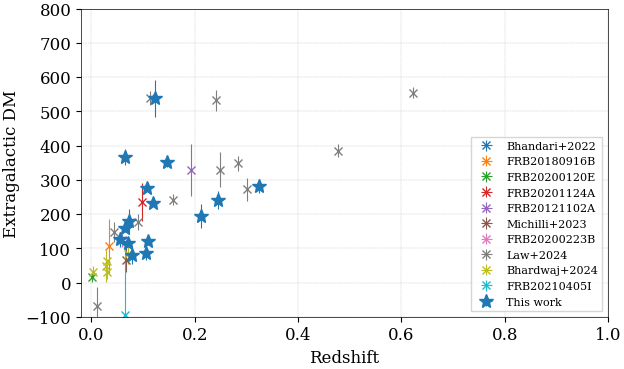

In [659]:
plt.style.use('/arc/home/calvin/kko_host_paper/plot_scripts/paper_sty.mplstyle')
z_max = 1.0
bhandari_keep = bhandari2021['primary_z_spec'] < z_max
bhardwaj_keep = bhardwaj2024['primary_z_spec'] < z_max
law_keep = dsa_110_frbs['primary_z_spec'] < z_max
leung_keep = (0 < final_zspec['primary_z_spec']) * (final_zspec['primary_P_Ox'] > 0.9)
michilli_keep = michilli2023['primary_z_spec'] < z_max
driessen_keep = driessen2024['primary_z_spec'] < z_max

plt.figure(figsize = (6.8,4))
plot_survey(bhandari2021[bhandari_keep],z_max = z_max,label = 'Bhandari+2022',ls='none',marker = 'x')
bhandari_chime = np.array([n in ['FRB20200120E','FRB20201124A','FRB20180916B'] for n in bhandari2021.index])
plot_zdm(bhandari2021[bhandari2021.index == 'FRB20180916B'],z_max = z_max,label = 'FRB20180916B',ls='none',marker = 'x')
plot_zdm(bhandari2021[bhandari2021.index == 'FRB20200120E'],z_max = z_max,label = 'FRB20200120E',ls='none',marker = 'x')
plot_zdm(bhandari2021[bhandari2021.index == 'FRB20201124A'],z_max = z_max,label = 'FRB20201124A',ls='none',marker = 'x')
plot_zdm(bhandari2021[bhandari2021.index == 'FRB20121102A'],z_max = z_max,label = 'FRB20121102A',ls='none',marker = 'x')
plot_zdm(michilli2023,z_max = z_max,label = 'Michilli+2023',ls='none',marker = 'x')
plot_zdm(ibik2023,z_max = z_max,label = 'FRB20200223B',ls='none',marker = 'x')
plot_zdm(dsa_110_frbs,z_max = z_max,label = 'Law+2024',linestyle='none',marker = 'x')
plot_zdm(bhardwaj2024,z_max = z_max,label = 'Bhardwaj+2024',ls='none',marker = 'x')
plot_zdm(driessen2024,z_max = z_max,label = 'FRB20210405I',ls='none',marker = 'x')
plot_zdm(final_zspec[leung_keep],z_max = z_max,label = 'This work',ls='none',marker = '*',markersize = 10)

#label_above_dmh(final[leung_keep],0)

#label_above_dmh(bhandari2021[bhandari2021.index != 'FRB20121102A'],200)
#label_above_dmh(dsa_110_frbs[law_keep],50)
plt.ylim(-100,800)
plt.xlim(-0.02,1)
plt.ylabel(r'Extragalactic DM')
plt.xlabel(f'Redshift')
plt.legend(loc = 'lower right',ncols = 1)
plt.savefig('/arc/home/calvin/kko_host_paper/figures/macquart.pdf',dpi = 100)

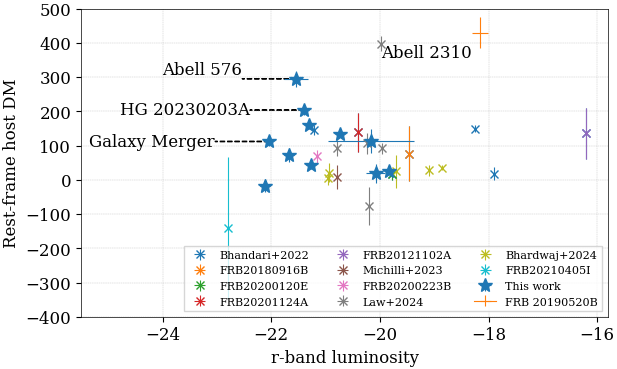

In [660]:
plt.style.use('/arc/home/calvin/kko_host_paper/plot_scripts/paper_sty.mplstyle')
z_max = 0.20
bhandari_keep = bhandari2021['primary_z_spec'] < z_max
bhardwaj_keep = bhardwaj2024['primary_z_spec'] < z_max
law_keep = dsa_110_frbs['primary_z_spec'] < z_max
leung_keep = (0 < final_zspec['primary_z_spec']) * (final_zspec['primary_P_Ox'] > 0.9)
michilli_keep = michilli2023['primary_z_spec'] < z_max
driessen_keep = driessen2024['primary_z_spec'] < z_max

plt.figure(figsize = (6.8,4))
plot_survey(bhandari2021[bhandari_keep],z_max = z_max,label = 'Bhandari+2022',ls='none',marker = 'x')
bhandari_chime = np.array([n in ['FRB20200120E','FRB20201124A','FRB20180916B'] for n in bhandari2021.index])
plot_survey(bhandari2021[bhandari2021.index == 'FRB20180916B'],z_max = z_max,label = 'FRB20180916B',ls='none',marker = 'x')
plot_survey(bhandari2021[bhandari2021.index == 'FRB20200120E'],z_max = z_max,label = 'FRB20200120E',ls='none',marker = 'x')
plot_survey(bhandari2021[bhandari2021.index == 'FRB20201124A'],z_max = z_max,label = 'FRB20201124A',ls='none',marker = 'x')
plot_survey(bhandari2021[bhandari2021.index == 'FRB20121102A'],z_max = z_max,label = 'FRB20121102A',ls='none',marker = 'x')
plot_survey(michilli2023,z_max = z_max,label = 'Michilli+2023',ls='none',marker = 'x')
plot_survey(ibik2023,z_max = z_max,label = 'FRB20200223B',ls='none',marker = 'x')
plot_survey(dsa_110_frbs,z_max = z_max,label = 'Law+2024',linestyle='none',marker = 'x')
plot_survey(bhardwaj2024,z_max = z_max,label = 'Bhardwaj+2024',ls='none',marker = 'x')
plot_survey(driessen2024,z_max = z_max,label = 'FRB20210405I',ls='none',marker = 'x')
plot_survey(final_zspec[leung_keep],z_max = z_max,label = 'This work',ls='none',marker = '*',markersize = 10)
label_df(dsa_110_frbs,name = 'FRB20220914A',s = 'Abell 2310',verticalalignment='top')
label_df(final_zspec,xoffset = -1,name = 342760050,s = 'Abell 576',verticalalignment='bottom',horizontalalignment='right') #FRB20231206A\n
label_df(final_zspec,xoffset = -1,name = 268786306,s = 'HG 20230203A',verticalalignment='center',horizontalalignment='right') #FRB20230203A\n
label_df(final_zspec,xoffset = -1,name = 342256558,s = 'Galaxy Merger',verticalalignment = 'center',horizontalalignment='right') #FRB20231204A\n

#label_above_dmh(final[leung_keep],0)

#label_above_dmh(bhandari2021[bhandari2021.index != 'FRB20121102A'],200)
#label_above_dmh(dsa_110_frbs[law_keep],50)
plt.errorbar(22.1 - Planck18.distmod(z = 0.22).value,430,xerr = 0.14, # flux error bar
             yerr = 113 * 0.4,label = 'FRB 20190520B') # J-band extinction at 1.2 microns
plt.ylim(-400,500)
plt.xlim(-25.5,-15.8)
plt.xlabel('r-band luminosity')
plt.ylabel('Rest-frame host DM')
plt.legend(loc = 'lower right',ncols = 3)
plt.savefig('/arc/home/calvin/kko_host_paper/figures/dm_host.pdf',dpi = 100)

# Combined sample

In [598]:
_no_clusters_with_low_dm = (dsa_110_frbs[law_keep * (dsa_110_frbs.index != 'FRB20220914A')],
        driessen2024[driessen_keep],
        bhandari2021[bhandari_keep * (bhandari2021.index != 'FRB20121102A')],
        final_zspec[leung_keep * (final_zspec.index != 342760050) * (final_zspec.index != 268786306) * (final_zspec.index != 342256558)],
        michilli2023[michilli_keep],
        ibik2023,
        bhardwaj2024
        )
no_clusters_with_low_dm = pd.concat([d[['M_r','DM_NE2001','DM_host_restframe','gal_b']] for d in _no_clusters_with_low_dm])

_with_clusters_with_low_dm = (dsa_110_frbs[law_keep],
        driessen2024[driessen_keep],
        bhandari2021[bhandari_keep * (bhandari2021.index != 'FRB20121102A')],
        final_zspec[leung_keep],
        michilli2023[michilli_keep],
        ibik2023,
        bhardwaj2024
        )
with_clusters_with_low_dm = pd.concat([d[['M_r','DM_NE2001','DM_host_restframe','gal_b']] for d in _with_clusters_with_low_dm])

_no_clusters_no_low_dm = (dsa_110_frbs[law_keep * (dsa_110_frbs.index != 'FRB20220914A')],
        driessen2024[driessen_keep],
        bhandari2021[bhandari_keep * (bhandari2021.index != 'FRB20121102A')],
        final_zspec[leung_keep * (final_zspec.index != 342760050) * (final_zspec.index != 268786306) * (final_zspec.index != 342256558)]
)
no_clusters_no_low_dm = pd.concat([d[['M_r','DM_NE2001','DM_host_restframe','gal_b']] for d in _no_clusters_no_low_dm])

_with_clusters_no_low_dm = (dsa_110_frbs[law_keep],
        driessen2024[driessen_keep],
        bhandari2021[bhandari_keep * (bhandari2021.index != 'FRB20121102A')],
        final_zspec[leung_keep]
)
with_clusters_no_low_dm = pd.concat([d[['M_r','DM_NE2001','DM_host_restframe','gal_b']] for d in _with_clusters_no_low_dm])

In [602]:
import numpy as np
from scipy.optimize import minimize,approx_fprime

# Function to fit mu and sigma using MLE
def fit_mu_sigma(dm,dm_err):
    assert len(dm) == len(dm_err)
    # Define the negative log-likelihood function for a normal distribution
    def neg_log_likelihood(params):
        mu, sigma2 = params
        # Avoid log(0) by ensuring sigma > 0
        if sigma2 <= 0:
            return np.inf
        # Compute the negative log-likelihood
        nll = 0.5 * np.sum(np.log(2 * np.pi * (sigma2 + dm_err**2 )) + 
                                  ((dm - mu)** 2) / (dm_err**2 + sigma2))
        return nll
    def jac(params):
        """d logL / dmu, d logL / dsigma"""
        sigma2 = params[1]
        mu = params[0]
        dn_dmu = -np.sum((dm - mu) / (sigma2 + dm_err**2))
        dn_dsigma = -0.5 * np.sum(
                (sigma2 + dm_err**2)**-1 - 
                (dm - mu)**2 / (sigma2 + dm_err**2)**2
        )
        return [dn_dmu, dn_dsigma]
    
    def hess(params):
        n = len(dm)
        sigma2 = params[1]
        mu = params[0]
        dn_dmumu = np.sum((dm_err**2 + sigma2)**-1)
        dn_dmusigma = np.sum((sigma2 + dm_err**2)**-2)
        dn_dsigsig = -0.5 * np.sum(-(sigma2 + dm_err**2)**-2 + 
                                   2 * (dm - mu)**2 / (sigma2 + dm_err**2)**3
                                  )
        return np.array([[dn_dmumu, dn_dmusigma],[dn_dmusigma,dn_dsigsig]])
        
    # Initial guesses for mu and sigma
    initial_guess = [np.mean(dm), np.std(dm_err)**2]
    
    # Minimize the negative log-likelihood
    result = minimize(neg_log_likelihood, initial_guess,  
                       jac = '2-point',hess='3-point')
    
    # Extract the fitted mu and sigma from the result
    mu_fit, sigma2_fit = result.x
    #hessian_inv = result.hess_inv  # Inverse of the Hessian (covariance matrix)

    # Standard errors (square roots of the diagonal elements of the covariance matrix)
    #standard_errors = np.sqrt(np.diag(hessian_inv))
    #hh = hess(result.x)
    #unc= np.sqrt(np.diag(np.linalg.inv(hh)))
    #print(result.inv_hess)
    #print(hh)
    
    mu_err,sigma2_err = np.diag(np.sqrt(result.hess_inv))
    return mu_fit,mu_err,np.sqrt(sigma2_fit),sigma2_err / (2 * np.sqrt(sigma2_fit))

import numpy as np
import matplotlib.pyplot as plt
def analyze_sample(df,label):
    mu,mu_err,sig,sig_err =  fit_mu_sigma(df['DM_host_restframe'],df['DM_NE2001'] * 0.4)
    print(f"{label}: $\mu = {mu:.2f} \pm {mu_err:.2f}$, $\sigma={sig:.2f} \pm {sig_err:.2f}$")

analyze_sample(no_clusters_no_low_dm[np.abs(no_clusters_no_low_dm['gal_b']) > 10],label = 'No clusters, no low-DM, |b| > 10')
analyze_sample(no_clusters_no_low_dm[np.abs(no_clusters_no_low_dm['gal_b']) > 5],label = 'No clusters, no low-DM, |b| > 5')
analyze_sample(no_clusters_with_low_dm[np.abs(no_clusters_with_low_dm['gal_b']) > 5],label = 'No clusters, with low-DM, |b| > 5')
analyze_sample(no_clusters_no_low_dm[(no_clusters_no_low_dm['M_r'] < -20.39) * np.abs(no_clusters_no_low_dm['gal_b']) > 5],
               label = 'No clusters, no low-DM, |b| > 5, non-luminous hosts')
analyze_sample(no_clusters_no_low_dm[(no_clusters_no_low_dm['M_r'] >= -20.39) * np.abs(no_clusters_no_low_dm['gal_b']) > 5],
               label = 'No clusters, no low-DM, |b| > 5, luminous hosts')

analyze_sample(with_clusters_no_low_dm[(with_clusters_no_low_dm['M_r'] < -20.39) * np.abs(with_clusters_no_low_dm['gal_b']) > 5],
               label = 'With clusters, no low-DM, |b| > 5, non-luminous hosts')
analyze_sample(with_clusters_no_low_dm[(with_clusters_no_low_dm['M_r'] >= -20.39) * np.abs(with_clusters_no_low_dm['gal_b']) > 5],
               label = 'With clusters, no low-DM, |b| > 5, luminous hosts')


No clusters, no low-DM, |b| > 10: $\mu = 62.10 \pm 15.24$, $\sigma=62.16 \pm 11.33$
No clusters, no low-DM, |b| > 5: $\mu = 59.99 \pm 15.36$, $\sigma=64.04 \pm 11.64$


/tmp/ipykernel_25199/3595038964.py:57: RuntimeWarning: invalid value encountered in sqrt
  mu_err,sigma2_err = np.diag(np.sqrt(result.hess_inv))


No clusters, with low-DM, |b| > 5: $\mu = 52.28 \pm 11.65$, $\sigma=56.72 \pm 9.01$
No clusters, no low-DM, |b| > 5, non-luminous hosts: $\mu = 86.69 \pm 20.22$, $\sigma=56.50 \pm 12.77$
No clusters, no low-DM, |b| > 5, luminous hosts: $\mu = 37.39 \pm 20.28$, $\sigma=62.74 \pm 15.90$
With clusters, no low-DM, |b| > 5, non-luminous hosts: $\mu = 116.30 \pm 23.42$, $\sigma=78.38 \pm 17.00$
With clusters, no low-DM, |b| > 5, luminous hosts: $\mu = 65.40 \pm 33.95$, $\sigma=118.52 \pm 25.26$


# Order the waterfalls

\includegraphics[width=0.22\textwidth]{FRB 20231025C_wfall.jpg}
\includegraphics[width=0.22\textwidth]{FRB 20231202A_wfall.jpg}
\includegraphics[width=0.22\textwidth]{FRB 20231201A_wfall.jpg}
\includegraphics[width=0.22\textwidth]{FRB 20231007B_wfall.jpg}
\includegraphics[width=0.22\textwidth]{FRB 20231204A_wfall.jpg}
\includegraphics[width=0.22\textwidth]{FRB 20231128A_wfall.jpg}
\includegraphics[width=0.22\textwidth]{FRB 20231206A_wfall.jpg}
\includegraphics[width=0.22\textwidth]{FRB 20230222A_wfall.jpg}
\includegraphics[width=0.22\textwidth]{FRB 20230926A_wfall.jpg}
\includegraphics[width=0.22\textwidth]{FRB 20230703A_wfall.jpg}
\includegraphics[width=0.22\textwidth]{FRB 20230203A_wfall.jpg}
\includegraphics[width=0.22\textwidth]{FRB 20231123A_wfall.jpg}
\includegraphics[width=0.22\textwidth]{FRB 20231223C_wfall.jpg}
\includegraphics[width=0.22\textwidth]{FRB 20231011A_wfall.jpg}
\includegraphics[width=0.22\textwidth]{FRB 20231025B_wfall.jpg}
\includegraphics[width=0.22\textwidth]{F

/tmp/ipykernel_25199/700083153.py:10: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  final_sorted[(final_sorted['primary_P_Ox'] > 0.9) * (0 < final['primary_z_spec']) * (final['primary_z_spec'] < 1)].index


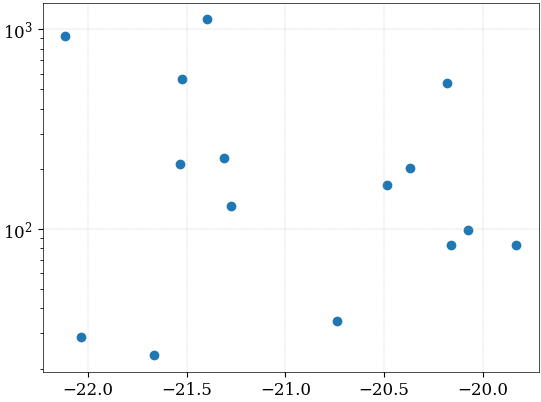

In [487]:
plt.figure()
plt.scatter(final_zspec['M_r'][leung_keep],
            final_zspec['fluence'][leung_keep] * 4 * np.pi* Planck18.luminosity_distance(final_zspec['primary_z_spec'][leung_keep])**2 / 1e6)
plt.yscale('log')

347261948
319829796


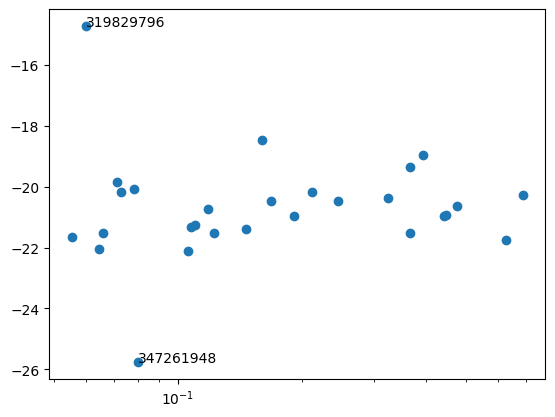

In [182]:
plt.figure()
plt.scatter(final['primary_z_spec'],final['primary_mag'] - final['extinction_mags'] - dist_mod)
for x,y,s in zip(final['primary_z_spec'],final['primary_mag'] - final['extinction_mags'] - dist_mod,final.index):
    if (y > -16 or y < -23) and x > 0:
        print(s)
        plt.text(x,y,s=s)
plt.xscale('log')

In [20]:
import matplotlib.pyplot as plt

/opt/pysetup/.venv/lib/python3.8/site-packages/pandas/core/arraylike.py:396: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/pysetup/.venv/lib/python3.8/site-packages/scipy/optimize/_minimize.py:550: RuntimeWarning: Method Nelder-Mead does not use gradient information (jac).
  warn('Method %s does not use gradient information (jac).' % method,
/opt/pysetup/.venv/lib/python3.8/site-packages/scipy/optimize/_minimize.py:555: RuntimeWarning: Method Nelder-Mead does not use Hessian information (hess).
  warn('Method %s does not use Hessian information (hess).' % method,


$\mu = 1.94 \pm 0.11$, $\sigma=0.37 \pm 0.15$
$\mu = 1.95 \pm 0.11$, $\sigma=0.42 \pm 0.15$
$\mu = 1.88 \pm 0.10$, $\sigma=0.40 \pm 0.23$


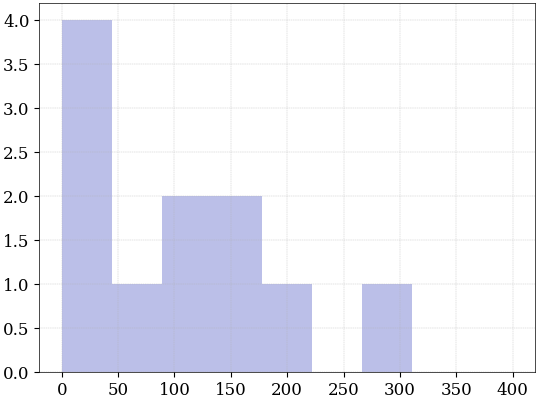

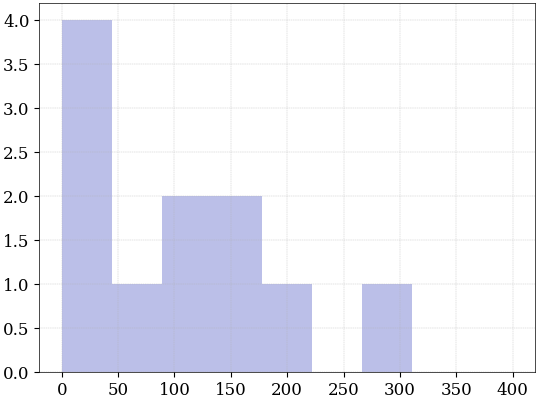

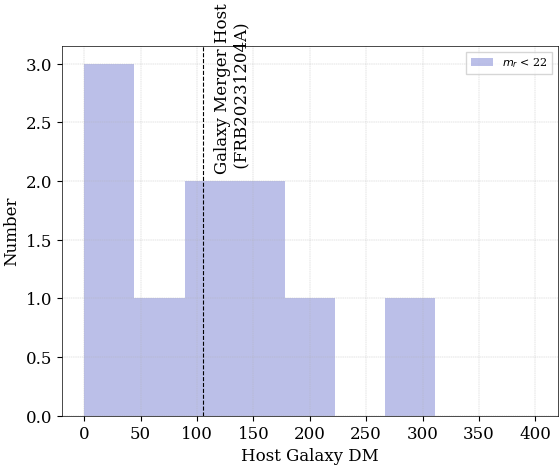

In [229]:
# Fiducial measurement: PATH P(O|x) > 0.9; m_r < 19.5; Use z_spec
fiducial = (final['primary_P_Ox'] > 0.9) * (final['primary_mag'] < 19.5) * (final['primary_z_spec'] > 0)
# Impact of relaxing PATH:
fiducial_lower_pox = (final['primary_P_Ox'] > 0.5) * (final['primary_mag'] < 19.5) * (final['primary_z_spec'] > 0)

fiducial_fainter_mag=(final['primary_P_Ox'] > 0.9) * (final['primary_mag'] < 22) * (final['primary_z_spec'] > 0)

plt.style.use('/arc/home/calvin/kko_host_paper/plot_scripts/paper_sty.mplstyle')
bins = np.linspace(0,400,num = 10)
dm_host = (final['DM'] - final['dm_igm'] - final['DM_NE2001'] - final['DM_YT20']) / (1 + final['primary_z_spec'])
plt.figure()
plt.hist(dm_host[fiducial_lower_pox],label = 'Lower P(O|x)',bins = bins,alpha = 0.3)
plt.figure()
plt.hist(dm_host[fiducial_fainter_mag],label = 'Fiducial',bins = bins,alpha = 0.3)
plt.figure()
plt.hist(dm_host[fiducial],label = '$m_r$ < 22',bins = bins,alpha = 0.3)
rest_frame_merger_dm = dm_host[final.index == 342256558].values / (1 + final['primary_z_spec'][final.index == 342256558].values)
plt.axvline(rest_frame_merger_dm,color = 'black',linestyle = '--')
plt.text(x = rest_frame_merger_dm + 10,y = 2.1,s = 'Galaxy Merger Host\n (FRB20231204A)',rotation = 90)
plt.legend()
plt.xlabel('Host Galaxy DM')
plt.ylabel('Number')
[mu,sig],[mu_err,sig_err] = fit_mu_sigma(np.log10(dm_host[fiducial]))
print(f"$\mu = {mu:.2f} \pm {mu_err:.2f}$, $\sigma={sig:.2f} \pm {sig_err:.2f}$")
[mu,sig],[mu_err,sig_err] = fit_mu_sigma(np.log10(dm_host[fiducial_lower_pox]))
print(f"$\mu = {mu:.2f} \pm {mu_err:.2f}$, $\sigma={sig:.2f} \pm {sig_err:.2f}$")
[mu,sig],[mu_err,sig_err] = fit_mu_sigma(np.log10(dm_host[fiducial_fainter_mag]))
print(f"$\mu = {mu:.2f} \pm {mu_err:.2f}$, $\sigma={sig:.2f} \pm {sig_err:.2f}$")
plt.savefig('/arc/home/calvin/kko_host_paper/figures/dm_host.pdf',dpi=100)

/opt/pysetup/.venv/lib/python3.8/site-packages/pandas/core/arraylike.py:396: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


TypeError: fit_mu_sigma() missing 1 required positional argument: 'dm_err'

In [349]:
final[(final['primary_P_Ox'] > 0.9) * (final['primary_z_spec'] > 0)][['name','primary_z_spec']]

,name,primary_z_spec
chime_event_id,,
325140573,FRB20231005A,0.0713
342256558,FRB20231204A,0.0644
339589360,FRB20231128A,0.1079
347082860,FRB20231223C,0.1059
330976597,FRB20231025B,0.3238
328261629,FRB20231017A,0.2450
321977347,FRB20230926A,0.0553
338403209,FRB20231123A,0.0729
326456063,FRB20231011A,0.0783


In [642]:
final_zspec.loc[[325140573, 268786306, 321977347]]

,name,ra_frb,dec_frb,b_err,a_err,gal_b,gal_l,DM_YT20,DM_NE2001,theta,...,secondary_mag,primary_z_spec_source,dm_igm,extinction_mags,flux,flux_err,fluence,fluence_err,M_r,DM_host_restframe
chime_event_id,,,,,,,,,,,,,,,,,,,,,
325140573,FRB20231005A,246.028004,35.448712,0.000556,0.003164,44.353154,57.165296,39.135917,33.4704,10.482417,...,22.138416,Lick-2024A-1,88.120924,0.041694,221.19,22.13,60.02,6.05,-19.832887,26.244328
268786306,FRB20230203A,151.661594,35.694096,0.000556,0.004994,54.087030,188.712544,29.021503,36.2627,10.148386,...,22.283922,Keck-2023B-3,118.715290,0.036518,6.15,0.65,173.03,17.40,-21.394736,203.508816
321977347,FRB20230926A,269.124876,41.814304,0.000556,0.004990,27.483988,68.235283,43.999481,52.6200,8.878110,...,20.396406,Lick-2024A-1,48.912551,0.090032,26.78,2.78,28.41,3.08,-21.665569,73.228650


# Inclination measurements

In [ ]:
chime_id 	TNS name    	ra       	dec       - inclinet using SDSS image - inclinet using deeper Pan-STARRS image
325140573	FRB20231005A	246.027572	35.446989 - 82,1          - 82, 0
342256558	FRB20231204A	207.999403	48.120566 - double galaxy - omit, double galaxy
339589360	FRB20231128A	199.580129	42.999713 - too faint     - 56, 3
347082860	FRB20231223C	259.544432	29.495848 - 49, 1         - 53,55; spiral structure visble so i think inclinet is wrong
330976597	FRB20231025B	270.786050	63.985568 - unresolved    - rejected 95%
330838705	FRB20231025C	71.974285	33.237527 - outside SDSS  - rejected 98%
328261629	FRB20231017A	346.753314	36.648447 - outside SDSS  - 69, 4 rejected 98%
321977347	FRB20230926A	269.124186	41.809999 - 73, 1         - 76, 1
338403209	FRB20231123A	82.622632	4.474384  - outside       - reject 99
341758878	FRB20231202A	65.030607	38.632866 - outside       - too faint
341477821	FRB20231201A	54.587601	26.812848 - outside       - 64, 4, reject 89%
326456063	FRB20231011A	18.241706	41.748995 - outside       - 
300938875	FRB20230703A	184.622792	48.725034 - irregular     - reject 100%
306528286	FRB20230730A	54.664905	33.160664 - outside       - faint
268786306	FRB20230203A	151.663820	35.697150 - 77, 1         - 81, 2
272350056	FRB20230222A	106.960492	11.222877 - outside       - no image?
272367619	FRB20230222B	238.737954	30.899874 - 48, 0 - 50, 5, 83% reject
342760050	FRB20231206A	112.443123	56.253245 - outside - 76, 1
325442526	FRB20231007B	307.529411	72.887196 - outside - 63, 6, 93% reject